In [1]:
from noema.params import DATA_PATH
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import numpy as np

In [2]:
data = pd.read_csv(f"{DATA_PATH}/noema_data_sigmoid.csv")
data.head(2)

,time,review,pcn,surgery,origin,review_word_count,embedding,ling_depth,sem_dispersion,semantic_density,actionability,richness_score
0,2024-01-01 10:51:00,Everyone kind and helpful,Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,4.0,"[0.009078879840672016, -0.019260024651885033, ...",0.480392,0.266753,0.374862,0.024609,0.245056
1,2024-01-02 07:58:00,"Denise was amazing, kind and helpful. The rece...",Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,23.0,"[-0.008330773562192917, 0.007228024769574404, ...",0.504202,0.559508,0.585369,0.531730,0.545094


In [3]:
data['embeddings'] = data['embedding'].apply(ast.literal_eval)

In [4]:
embeddings = data['embeddings'].tolist()

In [5]:
data['time'] = pd.to_datetime(data['time'])

In [20]:
data['dayofyear'] = data['time'].dt.dayofyear

In [26]:
data['weekofyear'] = data['time'].dt.isocalendar().week

In [32]:
data['monthofyear'] = data['time'].dt.month

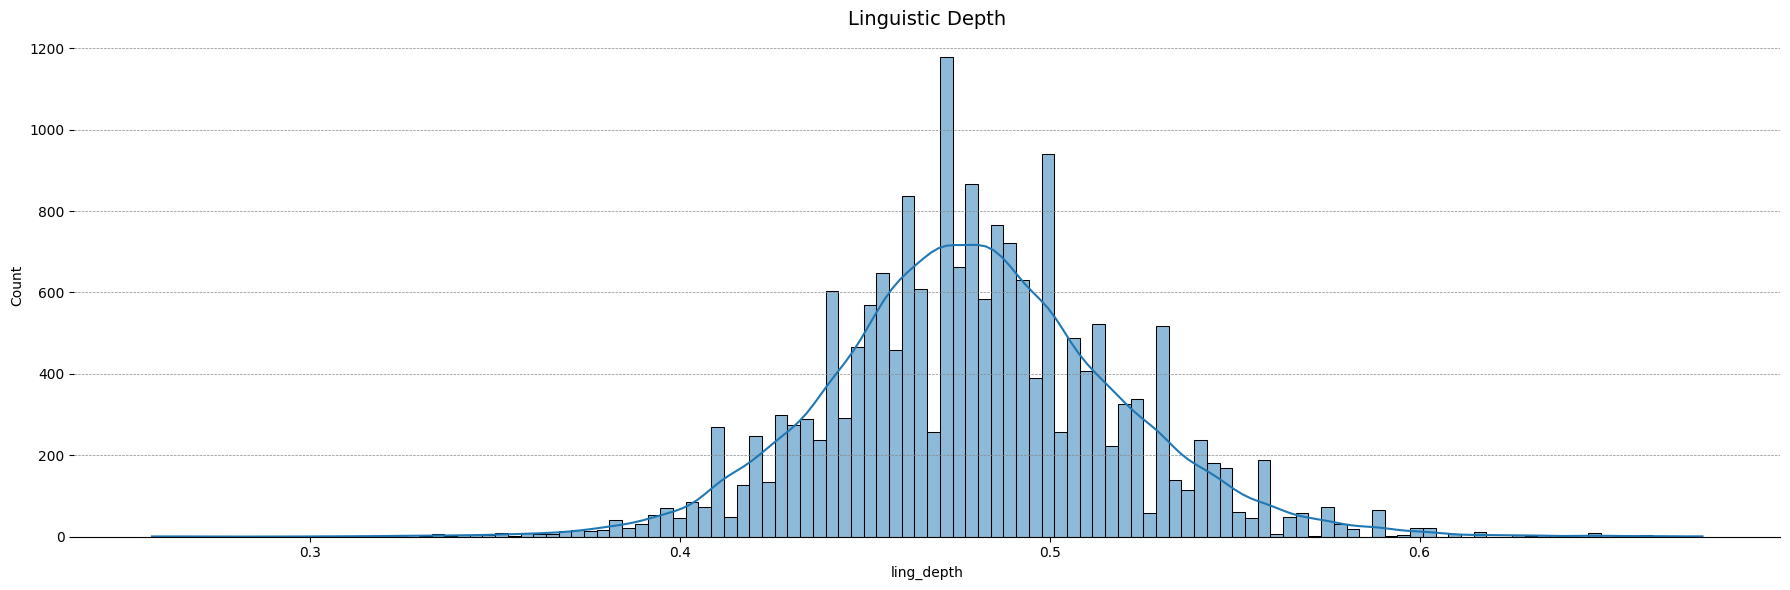

In [6]:
plt.figure(figsize=(18,6))
ax = sns.histplot(data['ling_depth'], kde=True)
# Remove top/right/left spines
sns.despine(right=True, top=True, left=True)

# Add horizontal gridlines
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#888888")

# Remove vertical gridlines
ax.xaxis.grid(False)

# Title
ax.set_title("Linguistic Depth", fontsize=14)

plt.tight_layout()
plt.show()

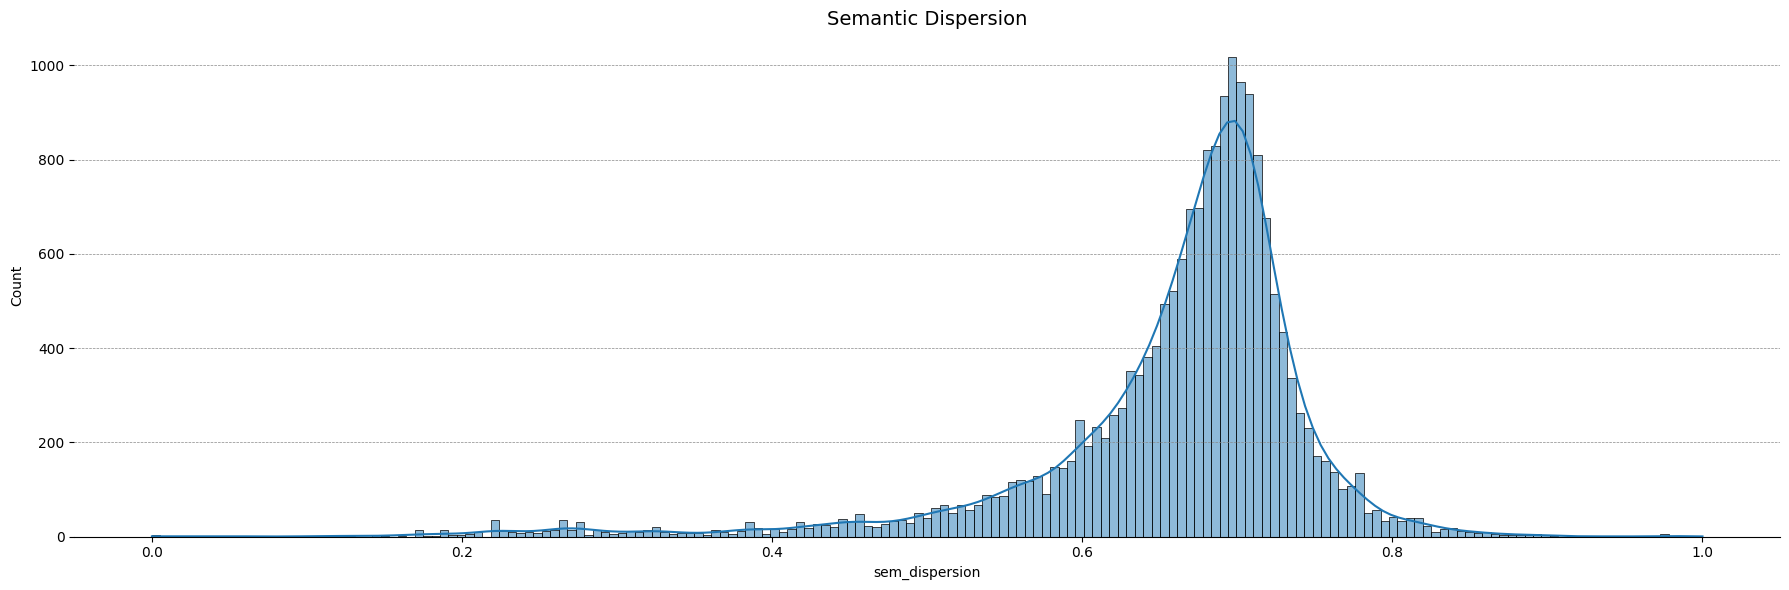

In [7]:
plt.figure(figsize=(18,6))
ax = sns.histplot(data['sem_dispersion'], kde=True)
# Remove top/right/left spines
sns.despine(right=True, top=True, left=True)

# Add horizontal gridlines
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#888888")

# Remove vertical gridlines
ax.xaxis.grid(False)

# Title
ax.set_title("Semantic Dispersion", fontsize=14)

plt.tight_layout()
plt.show()

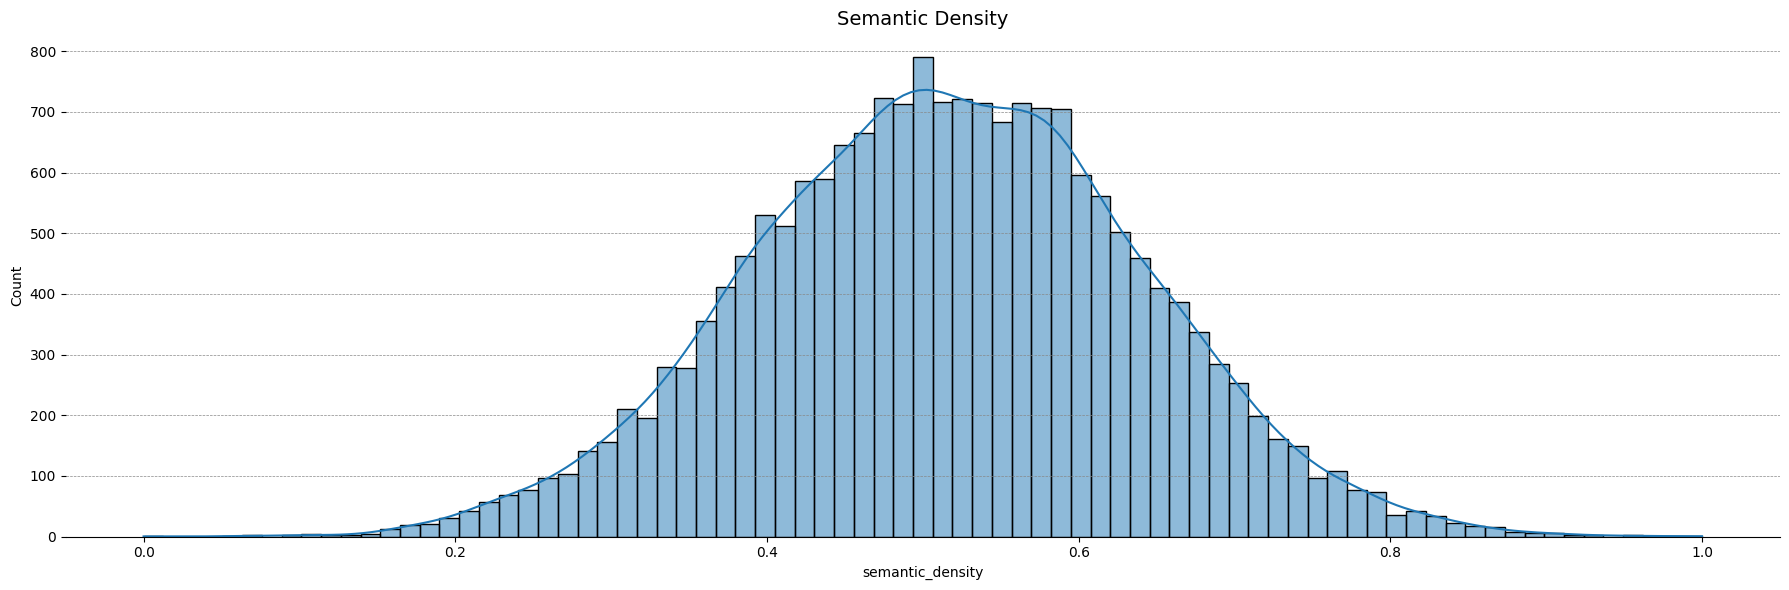

In [8]:
plt.figure(figsize=(18,6))
ax = sns.histplot(data['semantic_density'], kde=True)
# Remove top/right/left spines
sns.despine(right=True, top=True, left=True)

# Add horizontal gridlines
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#888888")

# Remove vertical gridlines
ax.xaxis.grid(False)

# Title
ax.set_title("Semantic Density", fontsize=14)

plt.tight_layout()
plt.show()

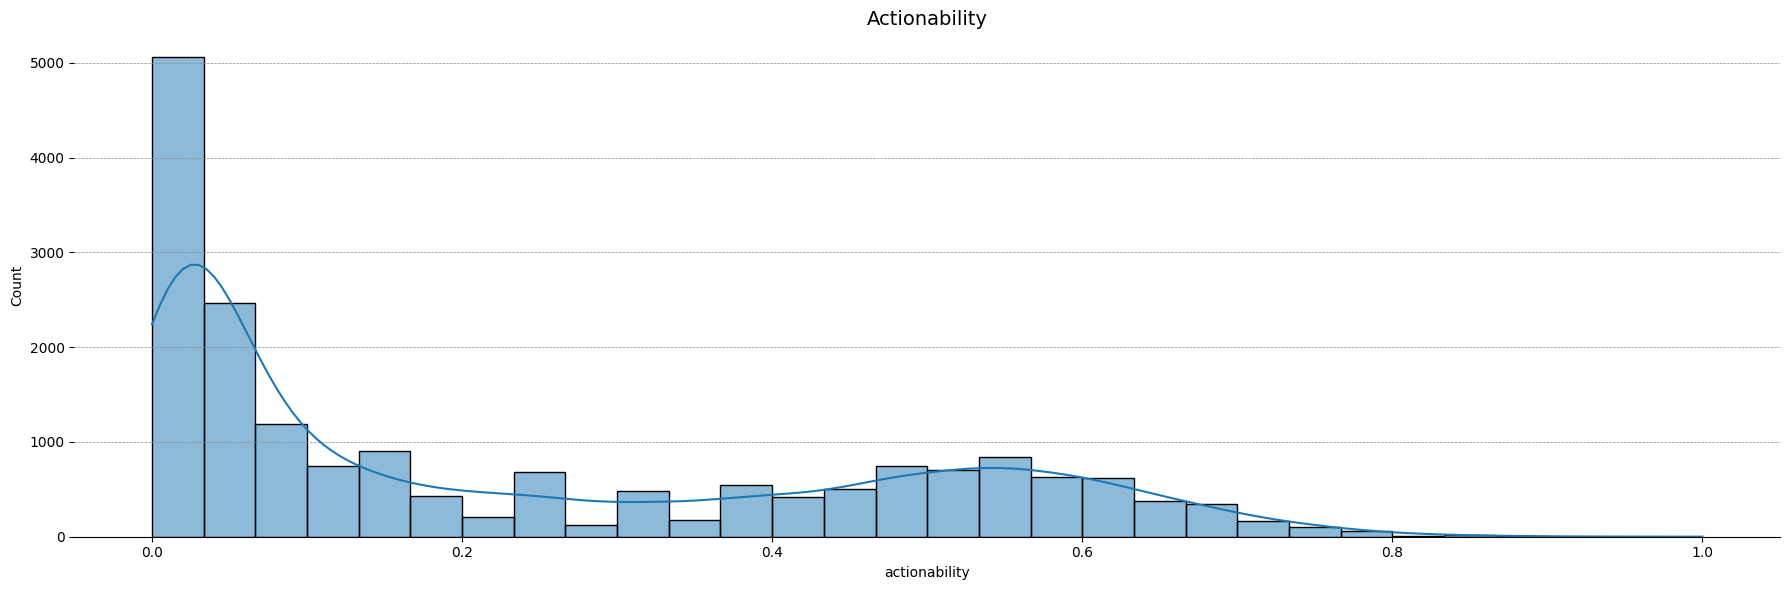

In [9]:
plt.figure(figsize=(18, 6))
ax = sns.histplot(data['actionability'], kde=True)

# Remove top/right/left spines
sns.despine(right=True, top=True, left=True)

# Add horizontal gridlines
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#888888")

# Remove vertical gridlines
ax.xaxis.grid(False)

# Title
ax.set_title("Actionability", fontsize=14)

plt.tight_layout()
plt.show()

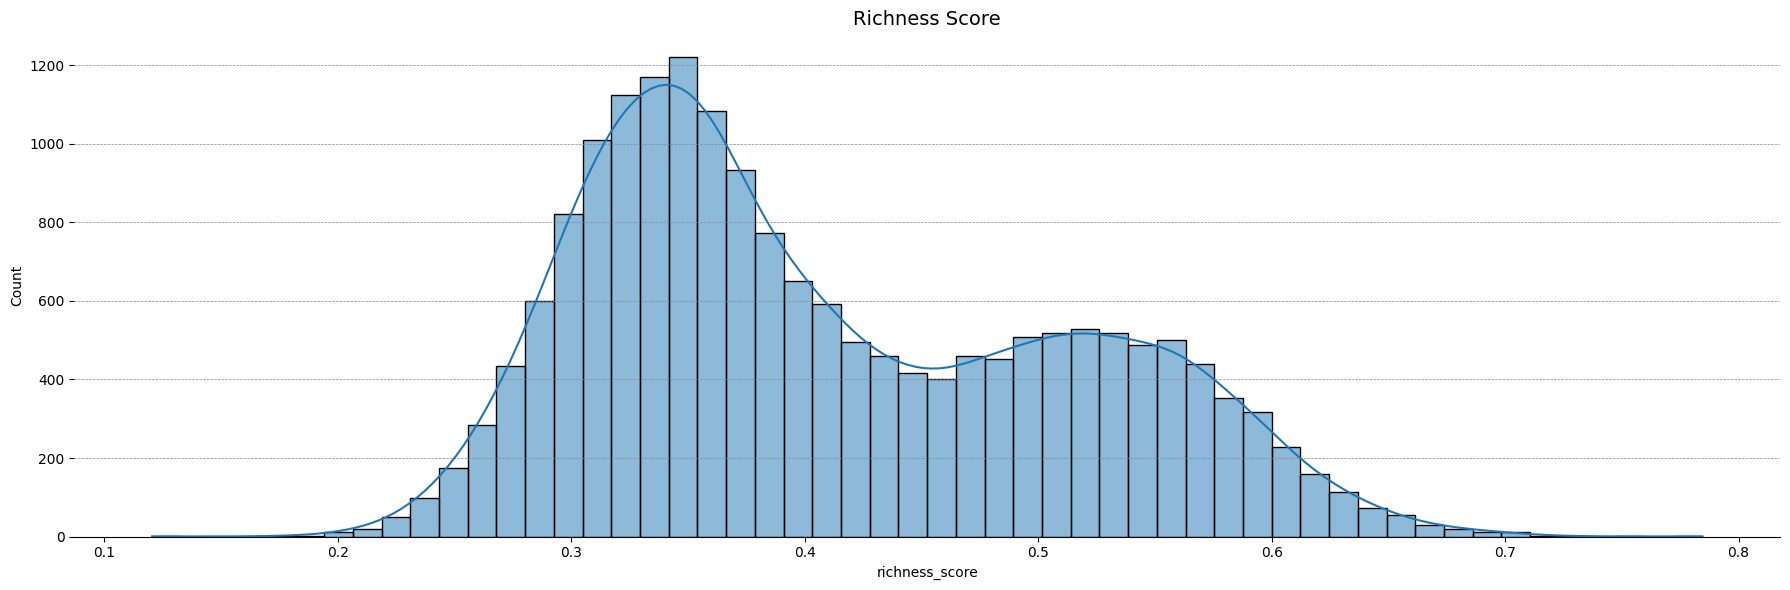

In [10]:
plt.figure(figsize=(18,6))
ax = sns.histplot(data['richness_score'], kde=True)
# Remove top/right/left spines
sns.despine(right=True, top=True, left=True)

# Add horizontal gridlines
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#888888")

# Remove vertical gridlines
ax.xaxis.grid(False)

# Title
ax.set_title("Richness Score", fontsize=14)

plt.tight_layout()
plt.show()

## **Richness Score** over time

<Axes: xlabel='monthofyear', ylabel='richness_score'>

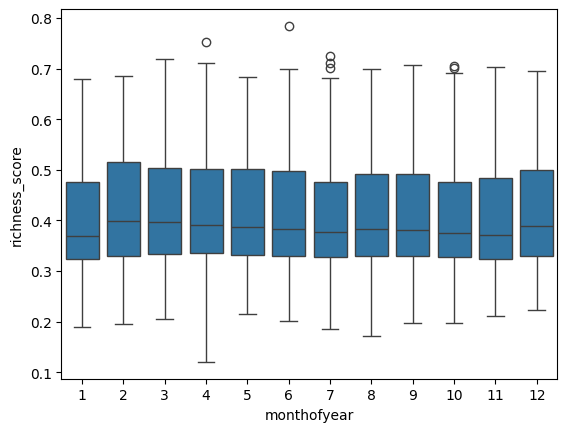

In [35]:
sns.boxplot(data=data, x='monthofyear', y='richness_score')

In [28]:
daily_mean = data.resample("D", on='time').agg({'richness_score': 'median'}).fillna(0).reset_index()
daily_mean.head(2)

,time,richness_score
0,2024-01-01,0.245056
1,2024-01-02,0.545094


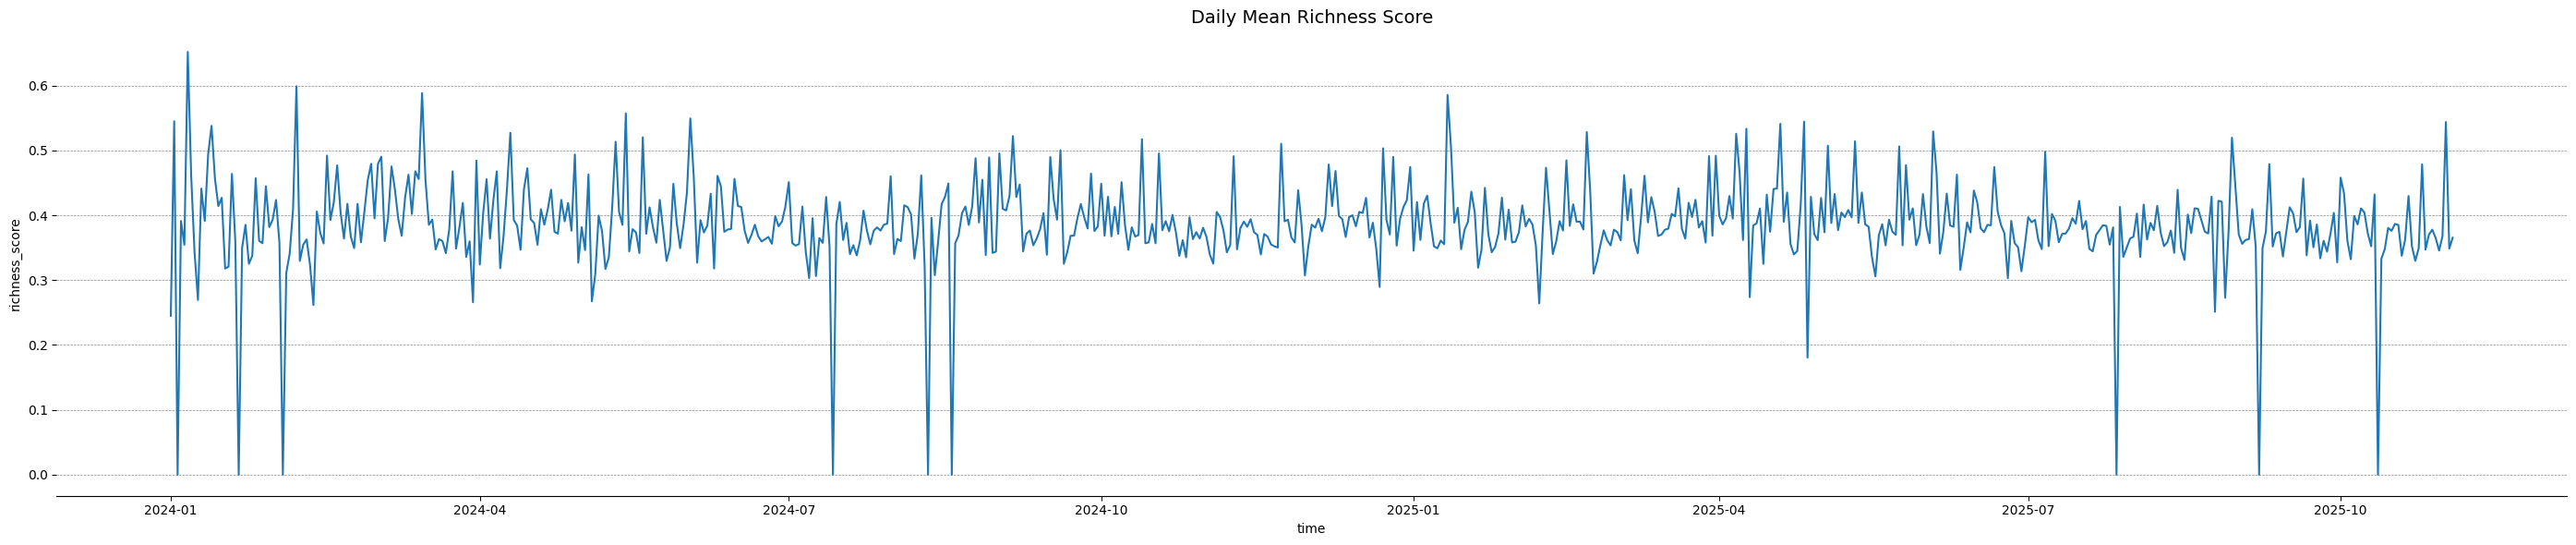

In [29]:
plt.figure(figsize=(28,6))
ax = sns.lineplot(data=daily_mean, x='time', y='richness_score')
# Remove top/right/left spines
sns.despine(right=True, top=True, left=True)

# Add horizontal gridlines
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#888888")

# Remove vertical gridlines
ax.xaxis.grid(False)

# Title
ax.set_title("Daily Mean Richness Score", fontsize=14)

plt.tight_layout()
plt.show()

In [30]:
weekly_mean = data.resample("W", on='time').agg({'richness_score': 'median'}).fillna(0).reset_index()
weekly_mean.head(2)

,time,richness_score
0,2024-01-07,0.376942
1,2024-01-14,0.373723


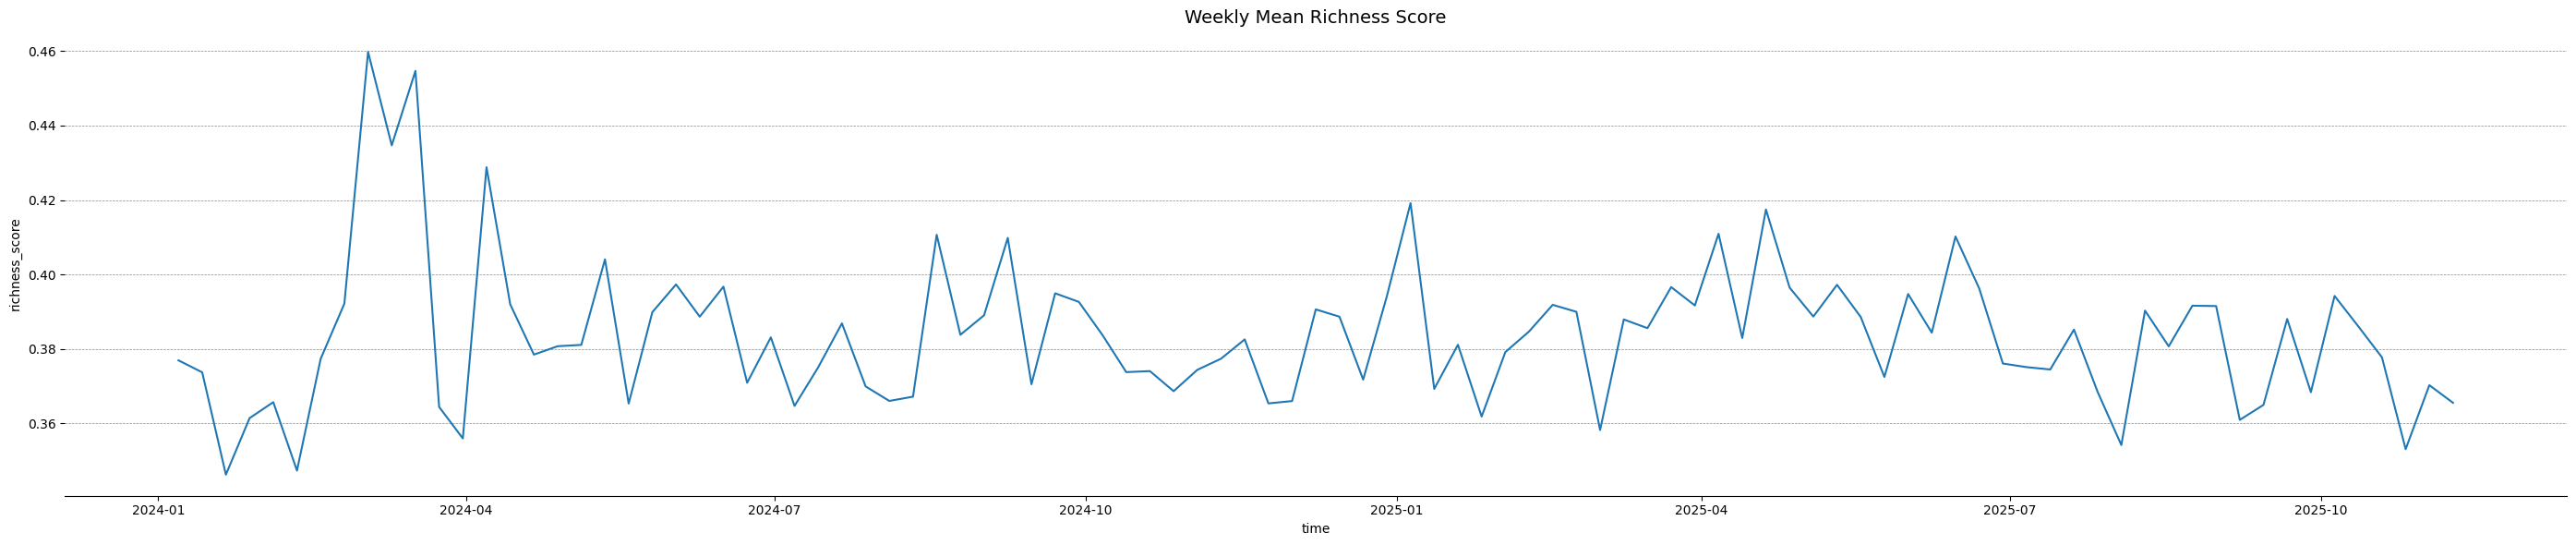

In [31]:
plt.figure(figsize=(28,6))
ax = sns.lineplot(data=weekly_mean, x='time', y='richness_score')
# Remove top/right/left spines
sns.despine(right=True, top=True, left=True)

# Add horizontal gridlines
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#888888")

# Remove vertical gridlines
ax.xaxis.grid(False)

# Title
ax.set_title("Weekly Mean Richness Score", fontsize=14)

plt.tight_layout()
plt.show()

## Setup **ChromDB** Vector Database to explore embeddings

Changepoints detected at indices: Richness Score of FFT Feedback


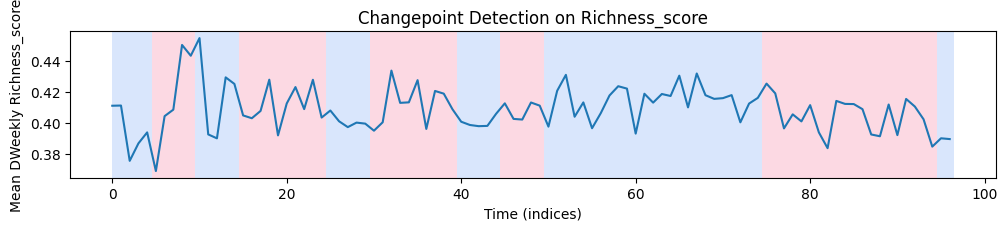

In [15]:
import ruptures as rpt

# Create a Pelt changepoint detection model
model = "rbf" # You can choose other models like 'l2', 'rbf', 'linear', etc.
algo = rpt.Pelt(model=model).fit(weekly_mean['richness_score'].values)

# Find changepoints
result = algo.predict(pen=0.5) # You might need to adjust the 'pen' value based on your data

# Print the changepoints
print(f"Changepoints detected at indices: Richness Score of FFT Feedback")

# You can also visualize the changepoints
rpt.display(weekly_mean['richness_score'].values, result)
plt.title(f"Changepoint Detection on Richness_score")
plt.xlabel("Time (indices)")
plt.ylabel("Mean DWeekly Richness_score")
plt.show()

In [16]:
import chromadb
from scipy.spatial.distance import cosine

# Initialize a persistent client (saves data to disk)
client = chromadb.PersistentClient(path=f"{DATA_PATH}/my_vector_db")

# Create a collection. Chroma will handle the embedding process for us using the model's embeddings.
collection_name = "gp_surgery_reviews"
collection = client.get_or_create_collection(
    name=collection_name,
    # Chroma will automatically use the default SentenceTransformer model if we don't specify one
)

print(f"✅ Collection '{collection_name}' created/loaded.")

✅ Collection 'gp_surgery_reviews' created/loaded.


In [17]:
documents = data['review'].tolist()

metadatas = [
    {"pcn": data['pcn'].tolist()},
    {"surgery": data['pcn'].tolist()},
    {"crichness_score": data['richness_score'].tolist()}
]
ids = [f"doc{i+1}" for i in range(len(documents))]

collection.add(
    documents=documents,
    metadatas=metadatas,
    ids=ids
)

print(f"\nAdded {len(documents)} documents to the collection.")

ValueError: Unequal lengths for fields: ids: 18608, metadatas: 3, documents: 18608 in add.

In [ ]:
# --- Extract components for ChromaDB ---
ids = data.index.tolist()
documents = data['review'].tolist()
metadatas = [
    {"pcn": data['pcn'].tolist()},
    {"surgery": data['surgery'].tolist()},
    {"crichness_score": data['richness_score'].tolist()}
]
# THIS IS THE KEY: Convert your embedding column into a list of lists
embeddings = data['embedding'].tolist()

print(f"Data prepared. Embedding dimension: {len(embeddings[0])}")

In [ ]:
# 3. Add documents using the pre-calculated 'embeddings' list
collection.add(
    ids=ids,
    embeddings=embeddings, # <--- THIS is where your Nomic vectors go
    documents=documents,
    metadatas=metadatas
)

print(f"\nAdded {len(documents)} documents with pre-calculated embeddings.")